# Hierarchical Clustering

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_excel('wine_dataset.xlsx', header=3)
X = dataset.iloc[:, 1:].values   # exclude Class column

## Feature Scaling

In [3]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X = sc.fit_transform(X)

## Using the dendrogram to find the optimal number of clusters

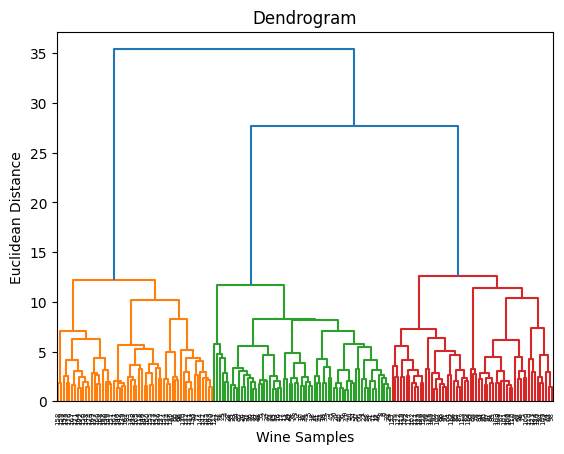

In [4]:
import scipy.cluster.hierarchy as sch

dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Wine Samples')
plt.ylabel('Euclidean Distance')
plt.show()

## Training the Hierarchical Clustering model on the dataset

In [5]:
from sklearn.cluster import AgglomerativeClustering

# dataset has 3 classes
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward') 
y_hc = hc.fit_predict(X)

## Visualising the clusters

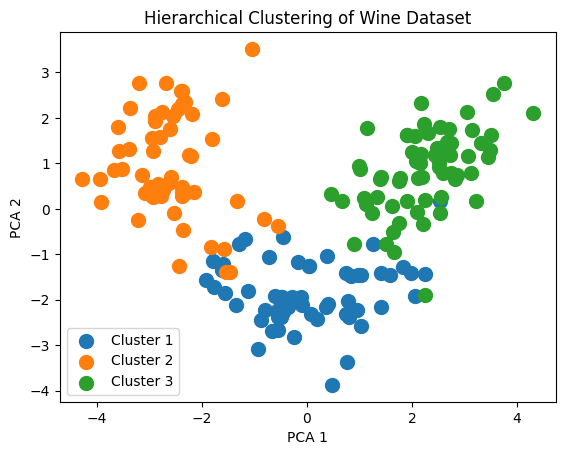

In [ ]:
from sklearn.decomposition import PCA

# reduce the dataset into 2 important dimensions for visualization
pca = PCA(n_components=2)

# actual transformation
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[y_hc == 0, 0], X_pca[y_hc == 0, 1], s=100, label='Cluster 1')
plt.scatter(X_pca[y_hc == 1, 0], X_pca[y_hc == 1, 1], s=100, label='Cluster 2')
plt.scatter(X_pca[y_hc == 2, 0], X_pca[y_hc == 2, 1], s=100, label='Cluster 3')

plt.title('Hierarchical Clustering of Wine Dataset')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()